In [1]:
import pandas as pd
import glob
import os

base_dir = r"D:\BLA_ChR_resp"

folders = [
    os.path.join(base_dir, "RI1_day1_boris"),
    os.path.join(base_dir, "RI1_day2_boris")
]

files = []
for f in folders:
    files.extend(glob.glob(os.path.join(f, "*.csv")))

# Exclude social-agent scoring
files = [f for f in files if not f.endswith("_sa.csv")]

len(files)


48

In [35]:
 for f in files:
     print(f)


D:\BLA_ChR_resp\RI1_day1_boris\1_1_RI1_f1_d_on_VT_BORIS_day1.csv
D:\BLA_ChR_resp\RI1_day1_boris\1_2_RI1_f2_f_off_20260109_165330.1_BORIS.csv
D:\BLA_ChR_resp\RI1_day1_boris\1_3_RI1_f1_c_off_20260110_130254.1_BORIS.csv
D:\BLA_ChR_resp\RI1_day1_boris\2_1_RI1_f2_h_on_VT.csv
D:\BLA_ChR_resp\RI1_day1_boris\2_2_RI1_f1_b_off_VT_BORIS_day1.csv
D:\BLA_ChR_resp\RI1_day1_boris\2_3_RI1_f2_f_on_VT_NEW.csv
D:\BLA_ChR_resp\RI1_day1_boris\3_1_RI1_f1_b_on_20260111_154618.1_BORIS.csv
D:\BLA_ChR_resp\RI1_day1_boris\3_2_RI1_f2_g_off_VT_BORIS_day1.csv
D:\BLA_ChR_resp\RI1_day1_boris\3_3_RI1_f1_c_on_VT.csv
D:\BLA_ChR_resp\RI1_day1_boris\4_1_RI1_f2_h_on_VT_BORIS_day1.csv
D:\BLA_ChR_resp\RI1_day1_boris\4_2_RI1_f1_c_off_VT.csv
D:\BLA_ChR_resp\RI1_day1_boris\4_3_RI1_f2_e_on_20260111_152801.1_BORIS.csv
D:\BLA_ChR_resp\RI1_day1_boris\5_1_RI1_m1_j_on_20260111_150428.1_BORIS.csv
D:\BLA_ChR_resp\RI1_day1_boris\5_2_RI1_m2_n_off_VT_BORIS_day1.csv
D:\BLA_ChR_resp\RI1_day1_boris\5_3_RI1_m1_k_off_VT.csv
D:\BLA_ChR_resp\RI1

In [4]:
def load_boris_for_inspection(csv_path):
    df = pd.read_csv(csv_path)

    # --- Standardize timing column names ---
    df = df.rename(columns={
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration"
    })

    # --- Keep only columns needed to LOOK at behavior ---
    keep_cols = [
        "Behavior",
        "Behavior type",
        "Subject",              # BORIS role: subject / agent
        "Start",
        "Stop",
        "Duration",
        "FPS (frame/s)",
        "Image index start",
        "Image index stop",
        "Media file name"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # --- Light cleaning ---
    df["Behavior"] = df["Behavior"].astype(str).str.strip().str.lower()
    df["Subject"] = df["Subject"].astype(str).str.strip().str.lower()

    # ============================
    # ADD METADATA FROM FILENAME
    # ============================
    fname = os.path.basename(csv_path)
    parts = fname.replace(".csv", "").split("_")

    # Subject ID = cage_mouse (e.g. 1_2)
    cage = parts[0]
    mouse = parts[1]
    subject_id = f"{cage}_{mouse}"

    # Laser condition
    laser = "ON" if "on" in parts else "OFF"

    df["SubjectID"] = subject_id
    df["Laser"] = laser

    return df


In [5]:
dfs = []
for f in files:
    df = load_boris_for_inspection(f)
    df["File"] = os.path.basename(f)
    dfs.append(df)

boris_df = pd.concat(dfs, ignore_index=True)



In [6]:
boris_df = boris_df.copy()

# Extract cage number from SubjectID (e.g. "3_2" → 3)
boris_df["Cage"] = boris_df["SubjectID"].str.split("_").str[0].astype(int)

# Assign group
boris_df["Group"] = boris_df["Cage"].apply(
    lambda x: "GFP" if x % 2 == 0 else "ChR-YFP"
)


In [7]:
boris_df.columns


Index(['Behavior', 'Behavior type', 'Subject', 'Start', 'Stop', 'Duration',
       'FPS (frame/s)', 'Image index start', 'Image index stop',
       'Media file name', 'SubjectID', 'Laser', 'File', 'Cage', 'Group'],
      dtype='object')

In [8]:
boris_df.shape
boris_df.head()


,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP


In [9]:
boris_df

,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,facial sniffing,STATE,subject,132.562,133.438,0.876,16.0,2122.0,2136.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1964,body sniffing,STATE,subject,133.562,134.438,0.876,16.0,2138.0,2152.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1965,anogenital sniffing,STATE,subject,135.312,136.000,0.688,16.0,2166.0,2177.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1966,facial sniffing,STATE,subject,157.750,158.312,0.562,16.0,2525.0,2534.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP


In [10]:
bout_counts = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser", "Behavior"], as_index=False)
    .size()
    .rename(columns={"size": "BoutCount"})
)


In [11]:
bout_counts.head()


,SubjectID,Group,Laser,Behavior,BoutCount
0,1_1,ChR-YFP,OFF,anogenital sniffing,13
1,1_1,ChR-YFP,OFF,body sniffing,6
2,1_1,ChR-YFP,OFF,chasing,2
3,1_1,ChR-YFP,OFF,facial sniffing,8
4,1_1,ChR-YFP,ON,anogenital sniffing,14


In [12]:
paired = (
    bout_counts
    .groupby(["SubjectID", "Group", "Behavior"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]   # must have ON + OFF

bout_counts_paired = bout_counts.merge(
    paired[["SubjectID", "Group", "Behavior"]],
    on=["SubjectID", "Group", "Behavior"],
    how="inner"
)


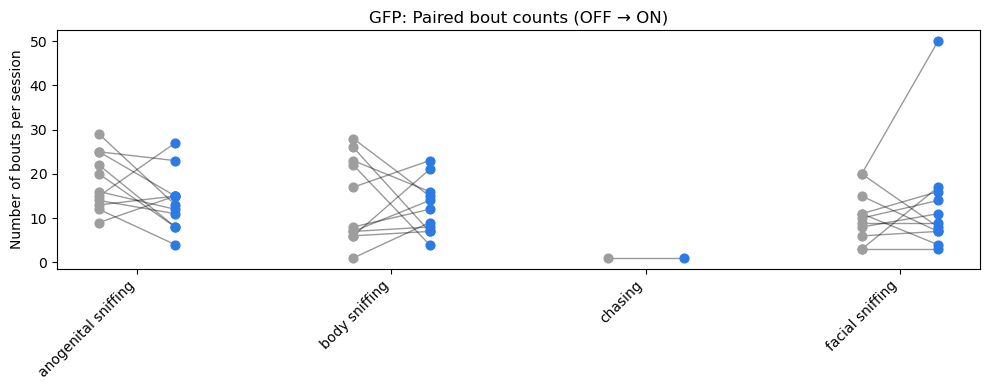

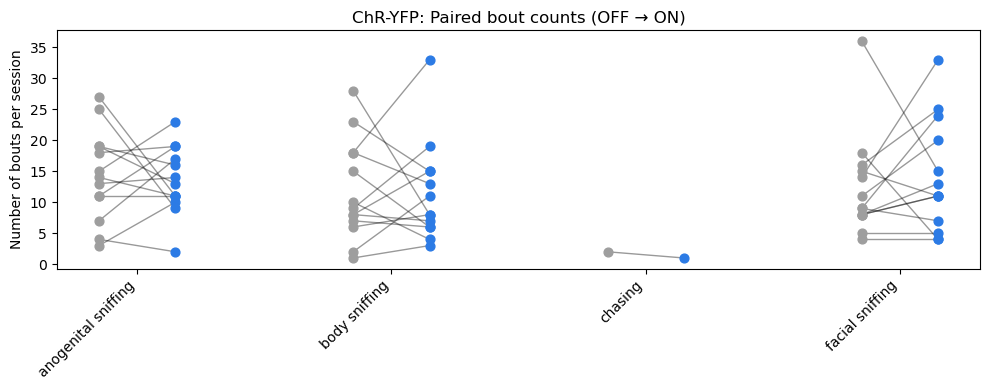

In [13]:
import matplotlib.pyplot as plt

groups = ["GFP", "ChR-YFP"]
colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}  # gray / blue

for group in groups:
    plt.figure(figsize=(10,4))

    gdf = bout_counts_paired[bout_counts_paired["Group"] == group]

    behaviors = sorted(gdf["Behavior"].unique())
    x_pos = {b: i for i, b in enumerate(behaviors)}

    for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):
        wide = sdf.pivot(index="SubjectID", columns="Laser", values="BoutCount")

        if not {"OFF", "ON"}.issubset(wide.columns):
            continue

        x = x_pos[beh]
        plt.plot(
            [x - 0.15, x + 0.15],
            [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
            color="black",
            alpha=0.4,
            linewidth=1
        )

        plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40, zorder=3)
        plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40, zorder=3)

    plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
    plt.ylabel("Number of bouts per session")
    plt.title(f"{group}: Paired bout counts (OFF → ON)")
    plt.tight_layout()
    plt.show()


In [14]:
print(bout_counts_paired.columns)


Index(['SubjectID', 'Group', 'Laser', 'Behavior', 'BoutCount'], dtype='object')


In [15]:
def infer_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    if cage <= 4:
        return "Female"
    else:
        return "Male"

bout_counts_paired["Sex"] = bout_counts_paired["SubjectID"].apply(infer_sex)


In [16]:
print(bout_counts_paired["Sex"].value_counts())


Sex
Female    74
Male      74
Name: count, dtype: int64


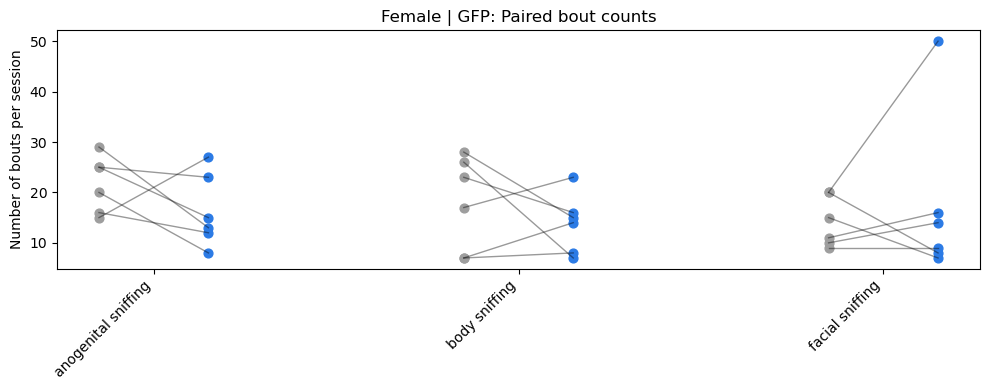

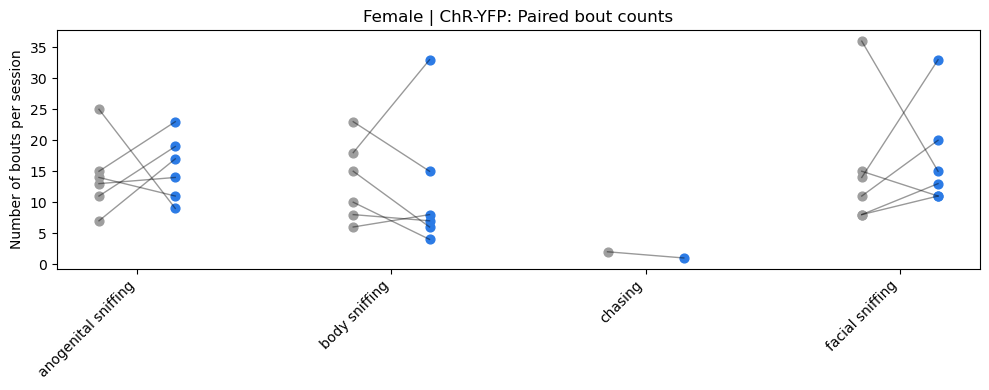

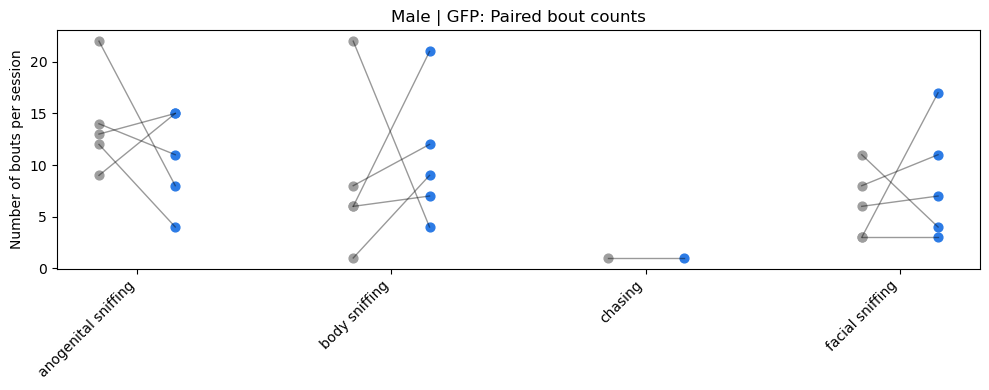

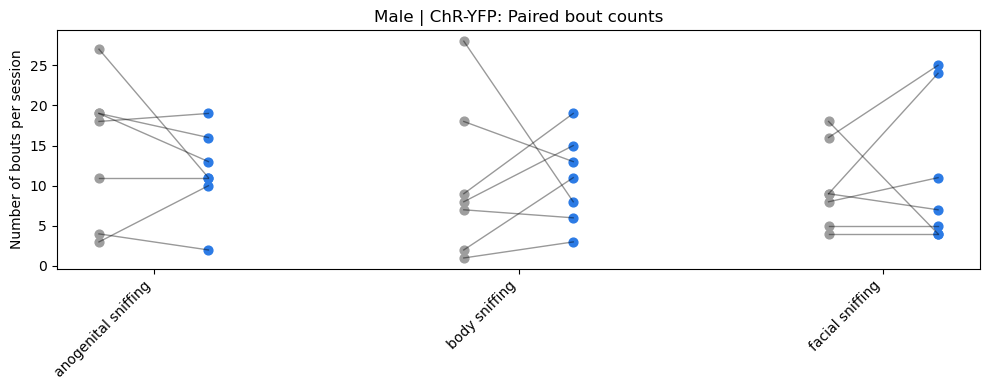

In [19]:
import matplotlib.pyplot as plt

groups = ["GFP", "ChR-YFP"]
sexes = ["Female", "Male"]

colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}

exclude_subjects = ["1.3", "3.3"]

filtered_df = bout_counts_paired[
    ~bout_counts_paired["SubjectID"].isin(exclude_subjects)
].copy()


for sex in sexes:
    for group in groups:

        plt.figure(figsize=(10,4))

        gdf = filtered_df[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Sex"] == sex)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            wide = sdf.pivot(index="SubjectID", columns="Laser", values="BoutCount")

            if not {"OFF", "ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
        plt.ylabel("Number of bouts per session")
        plt.title(f"{sex} | {group}: Paired bout counts")
        plt.tight_layout()
        plt.show()



In [20]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]


In [21]:
invest_df = boris_df[
    boris_df["Behavior"].isin(investigation_behaviors)
].copy()

invest_time = (
    invest_df
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [22]:
invest_time.head()
invest_time.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      13
         ON       13
GFP      OFF      11
         ON       11
dtype: int64

In [23]:
file_presence = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_presence[file_presence["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,N_files
8,2_2,GFP,OFF,1
9,2_2,GFP,ON,1
42,8_2,GFP,OFF,1
43,8_2,GFP,ON,1


In [59]:
# All OFF sessions (regardless of behavior)
all_off_files = (
    boris_df[boris_df["Laser"] == "OFF"]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_files")
)

# OFF sessions WITH investigation
off_invest = (
    boris_df[
        (boris_df["Laser"] == "OFF") &
        (boris_df["Behavior"].isin([
            "facial sniffing",
            "body sniffing",
            "anogenital sniffing"
        ]))
    ]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_invest_files")
)

check = (
    all_off_files
    .merge(off_invest, on=["SubjectID", "Group"], how="left")
    .fillna({"N_OFF_invest_files": 0})
)

check[check["Group"] == "GFP"]


,SubjectID,Group,N_OFF_files,N_OFF_invest_files
3,2_1,GFP,1,1
4,2_2,GFP,1,1
5,2_3,GFP,1,1
9,4_1,GFP,1,1
10,4_2,GFP,1,1
11,4_3,GFP,1,1
15,6_2,GFP,1,1
16,6_3,GFP,1,1
20,8_1,GFP,1,1
21,8_2,GFP,1,1


In [60]:
exclude_subjects = ["1.3", "3.3"]

invest_time_paired = invest_time[
    ~invest_time["SubjectID"].isin(exclude_subjects)
].copy()


In [61]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_time_paired = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)


In [38]:
invest_time_paired.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      13
         ON       13
GFP      OFF      11
         ON       11
dtype: int64

In [39]:
invest_plot = invest_time_paired.copy()


In [40]:
invest_plot.columns


Index(['SubjectID', 'Group', 'Laser', 'InvestigationTime'], dtype='object')

C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\274188041.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


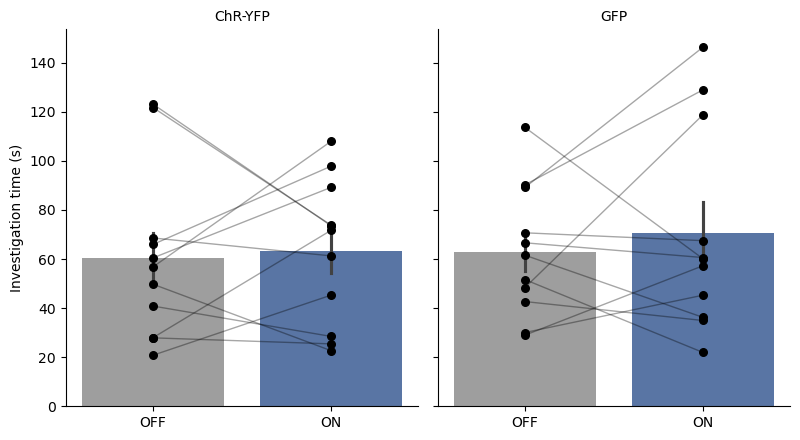

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


exclude_subjects = ["1_3", "3_3"]

invest_plot = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    palette=palette_laser,
    errorbar="se",      # ✅ FIXED
    height=4.5,
    aspect=0.9,
    sharey=True
)

# Overlay paired points + lines
for ax, (group, df_group) in zip(g.axes.flat, invest_plot.groupby("Group")):
    for subject, df_sub in df_group.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\1847937394.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


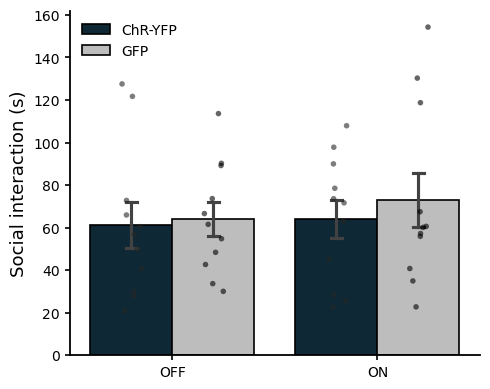

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


exclude_subjects = ["1_3", "3_3"]

invest_plot = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()

# --- Orders ---
laser_order = ["OFF", "ON"]
group_order = ["ChR-YFP", "GFP"]

# --- Colors ---
group_palette = {
    "ChR-YFP": "#072B3B",  # purple
    "GFP": "#BDBDBD"       # gray
}

plt.figure(figsize=(5, 4))

# --- Bar plot (mean ± SEM) ---
sns.barplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    errorbar="se",
    palette=group_palette,
    edgecolor="black",
    linewidth=1.2,
    capsize=0.1
)

# --- Overlay jittered individual points ---
sns.stripplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    dodge=True,
    color="black",
    size=4,
    alpha=0.6
)

# --- Clean up double legend (stripplot adds another) ---
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False)

# --- Style like paper ---
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)

ax.set_ylabel("Social interaction (s)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(width=1.2)

plt.tight_layout()
plt.show()


In [63]:
print(invest_plot["Group"].unique())
print(invest_plot["Laser"].unique())
print(invest_plot.head())


['ChR-YFP' 'GFP']
['OFF' 'ON']
  SubjectID    Group Laser  InvestigationTime
0       1_1  ChR-YFP   OFF             72.801
1       1_1  ChR-YFP    ON             62.983
2       1_2  ChR-YFP   OFF             40.841
3       1_2  ChR-YFP    ON             28.480
6       2_1      GFP   OFF             66.622


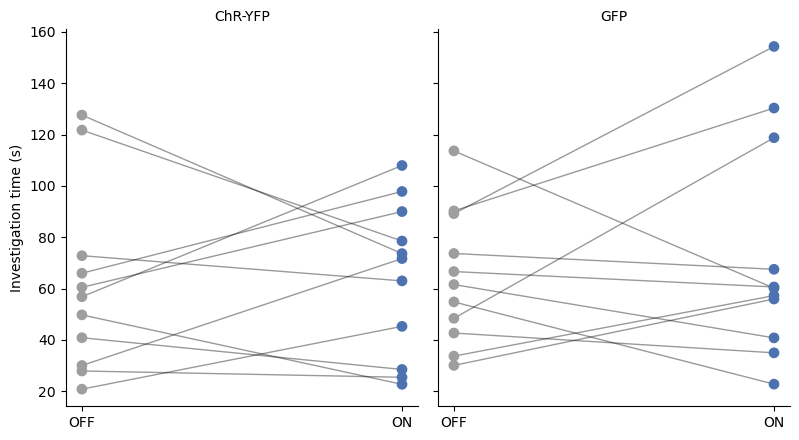

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

exclude_subjects = ["1_3", "3_3"]

invest_plot = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")  # OFF -> ON
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [45]:
(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .pivot_table(
        index=["Behavior", "Group"],
        columns="Laser",
        values="File",     # any column works, we just count rows
        aggfunc="count",
        fill_value=0
    )
    .sort_values(["Group"], ascending=True)
)


,Laser,OFF,ON
Behavior,Group,,
allogrooming,ChR-YFP,3,0
anogenital sniffing,ChR-YFP,186,175
body sniffing,ChR-YFP,153,148
chasing,ChR-YFP,8,6
facial sniffing,ChR-YFP,161,183
self-grooming,ChR-YFP,1,3
anogenital sniffing,GFP,200,151
body sniffing,GFP,151,136
chasing,GFP,9,23


In [46]:
# Create the summary table
summary_table = (
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .pivot_table(
        index=["Behavior", "Group"],
        columns="Laser",
        values="File",
        aggfunc="count",
        fill_value=0
    )
    .sort_values(["Group"], ascending=True)
)

# Reset index so Behavior and Group become normal columns
summary_table = summary_table.reset_index()

# Optional: remove the column name "Laser" from the header
summary_table.columns.name = None

# Save to CSV
summary_table.to_csv("boris_behavior_laser_counts.csv", index=False)

print("CSV saved successfully.")


CSV saved successfully.


In [47]:
summary_table.head()

,Behavior,Group,OFF,ON
0,allogrooming,ChR-YFP,3,0
1,anogenital sniffing,ChR-YFP,186,175
2,body sniffing,ChR-YFP,153,148
3,chasing,ChR-YFP,8,6
4,facial sniffing,ChR-YFP,161,183


In [48]:
import os
print(os.getcwd())


c:\Users\sjs93\OneDrive\Documents\respiratory_pilot


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\3392186456.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\3392186456.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


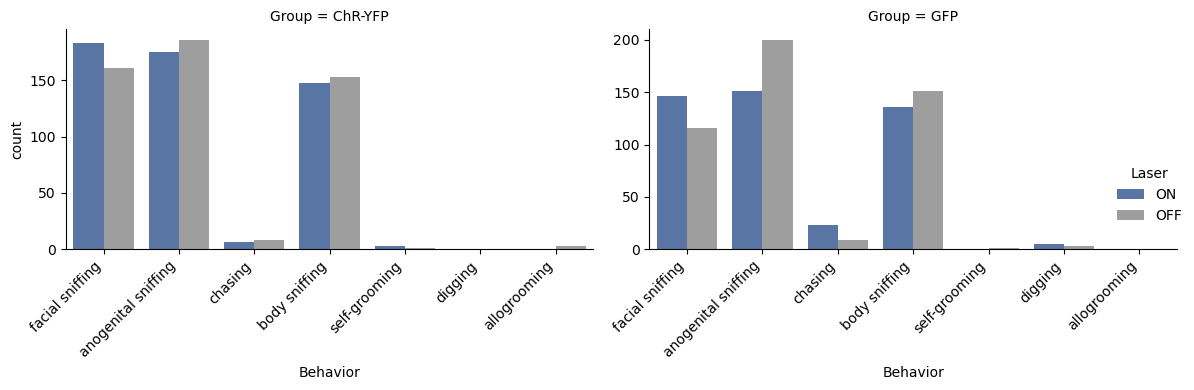

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

exclude_subjects = ["1_3", "3_3"]

invest_plot = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()
palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=boris_df.assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    ),
    x="Behavior",
    hue="Laser",
    col="Group",
    kind="count",
    palette=palette_laser,
    height=4,
    aspect=1.4,
    sharey=False
)

# 🔄 Rotate x-axis labels to 45°
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



In [51]:

(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .groupby(["Group", "Laser", "Behavior"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Group", "Laser", "Count"], ascending=[True, True, False])
)



,Group,Laser,Behavior,Count
1,ChR-YFP,OFF,anogenital sniffing,186
4,ChR-YFP,OFF,facial sniffing,161
2,ChR-YFP,OFF,body sniffing,153
3,ChR-YFP,OFF,chasing,8
0,ChR-YFP,OFF,allogrooming,3
5,ChR-YFP,OFF,self-grooming,1
9,ChR-YFP,ON,facial sniffing,183
6,ChR-YFP,ON,anogenital sniffing,175
7,ChR-YFP,ON,body sniffing,148
8,ChR-YFP,ON,chasing,6


In [52]:
(
    boris_df["Behavior"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)


Behavior
anogenital sniffing    712
facial sniffing        606
body sniffing          588
chasing                 46
digging                  8
self-grooming            5
allogrooming             3
Name: count, dtype: int64

In [53]:
exclude_behaviors = ["self-grooming", "digging"]

investigation_behaviors = (
    boris_df["Behavior"]
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
)

investigation_behaviors = [
    b for b in investigation_behaviors
    if b not in exclude_behaviors
]

investigation_behaviors


['facial sniffing',
 'anogenital sniffing',
 'chasing',
 'body sniffing',
 'allogrooming']

In [54]:
invest_time = (
    boris_df
    .assign(Behavior=lambda df: df["Behavior"].str.lower().str.strip())
    .query("Behavior in @investigation_behaviors")
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [55]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_plot = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)


In [66]:
invest_plot.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      11
         ON       11
GFP      OFF      11
         ON       11
dtype: int64

In [67]:
invest_plot.columns.tolist()


['SubjectID', 'Group', 'Laser', 'InvestigationTime']

In [68]:
def subject_to_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    return "Female" if cage <= 4 else "Male"

invest_plot = invest_plot.copy()
invest_plot["SubjSex"] = invest_plot["SubjectID"].apply(subject_to_sex)


In [69]:
invest_plot[["SubjectID", "SubjSex"]].drop_duplicates().sort_values("SubjectID")


,SubjectID,SubjSex
0,1_1,Female
2,1_2,Female
6,2_1,Female
8,2_2,Female
10,2_3,Female
12,3_1,Female
14,3_2,Female
18,4_1,Female
20,4_2,Female
22,4_3,Female


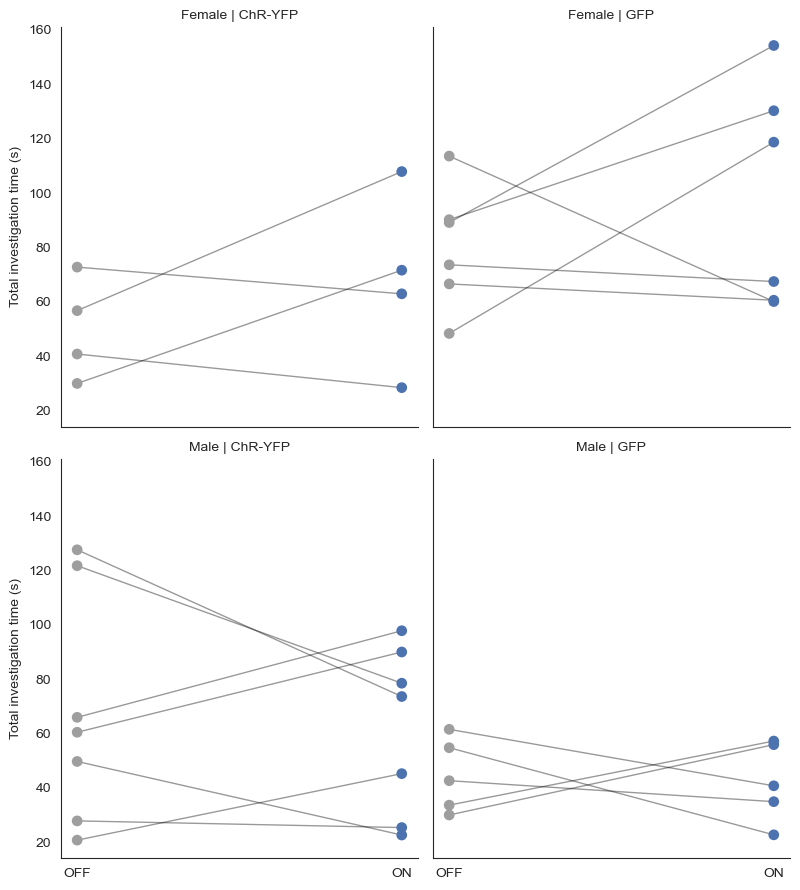

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"OFF", "ON"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{row_name} | {col_name}")
plt.tight_layout()
plt.show()


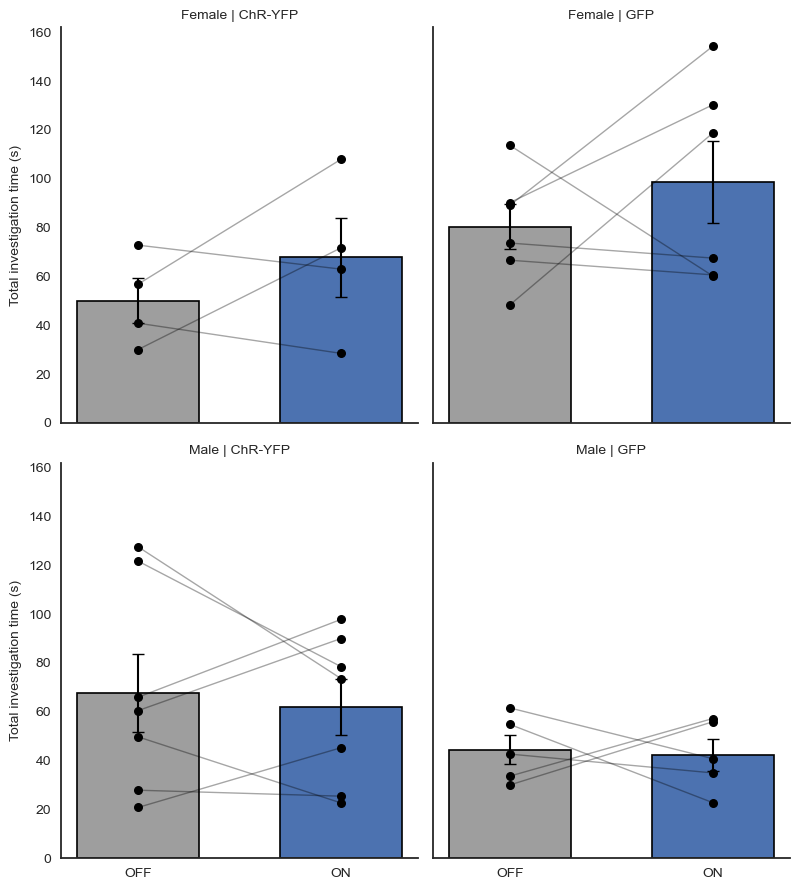

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

palette_laser = {
    "OFF": "#9E9E9E",
    "ON": "#4C72B0"
}

laser_order = ["OFF", "ON"]

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    # --- Compute means + SEM ---
    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    # --- Plot bars ---
    x = np.arange(len(laser_order))

    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[palette_laser[l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Overlay paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


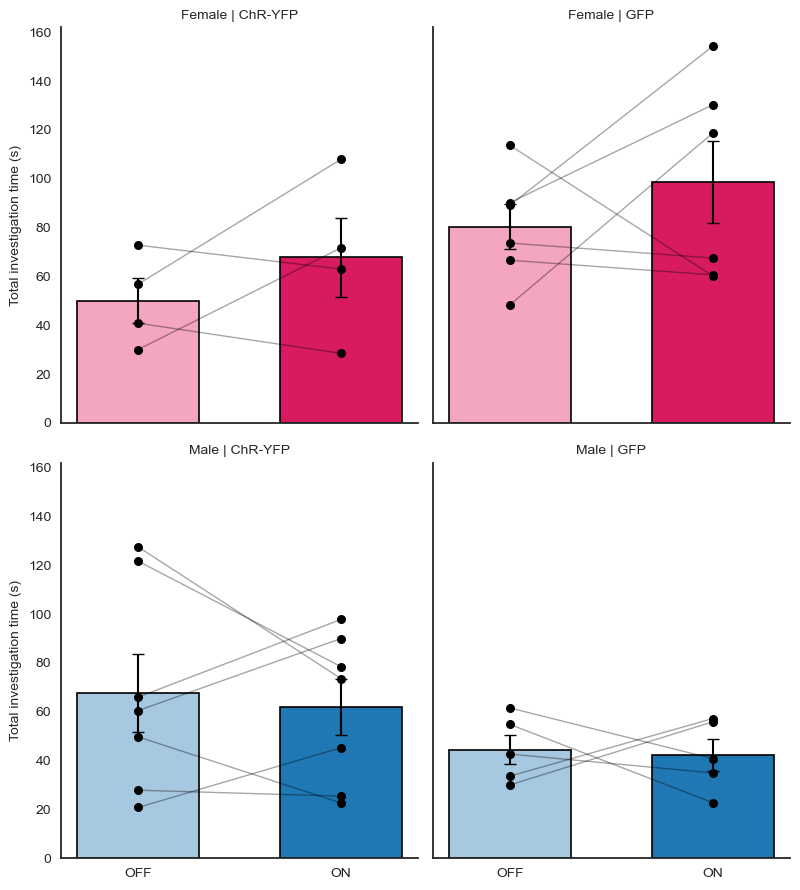

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

exclude_subjects = ["1_3", "3_3"]

invest_plot = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()


sns.set_style("white")

laser_order = ["OFF", "ON"]

# --- Sex-specific color palettes ---
sex_palette = {
    "Female": {
        "OFF": "#F4A6C1",   # light pink
        "ON":  "#D81B60"    # darker pink
    },
    "Male": {
        "OFF": "#A6C8E0",   # light blue
        "ON":  "#1F77B4"    # darker blue
    }
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    sex = data["SubjSex"].iloc[0]  # get sex for this panel

    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    x = np.arange(len(laser_order))

    # --- Bars colored by sex ---
    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[sex_palette[sex][l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


In [74]:
exclude_subjects = ["1_3", "3_3"]  # adjust format if needed

invest_plot_clean = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()


In [76]:
print(invest_plot_clean["SubjectID"].unique())


['1_1', '1_2', '2_1', '2_2', '2_3', ..., '7_3', '8_1', '8_2', '8_3', '9_1']
Length: 22
Categories (22, object): ['1_1', '1_2', '2_1', '2_2', ..., '8_1', '8_2', '8_3', '9_1']


In [80]:
exclude_subjects = ["1_3", "3_3"]

invest_clean = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()


In [81]:
import statsmodels.formula.api as smf

female_df = invest_clean[invest_clean["SubjSex"] == "Female"].copy()

female_df["Group"] = female_df["Group"].astype("category")
female_df["Laser"] = female_df["Laser"].astype("category")
female_df["SubjectID"] = female_df["SubjectID"].astype("category")

model_f = smf.mixedlm(
    "InvestigationTime ~ Group * Laser",
    data=female_df,
    groups="SubjectID"
)

result_f = model_f.fit()
print("FEMALES")
print(result_f.summary())


FEMALES
               Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  InvestigationTime
No. Observations:   20       Method:              REML             
No. Groups:         10       Scale:               941.6105         
Min. group size:    2        Log-Likelihood:      -80.7244         
Max. group size:    2        Converged:           Yes              
Mean group size:    2.0                                            
-------------------------------------------------------------------
                         Coef.  Std.Err.   z   P>|z|  [0.025 0.975]
-------------------------------------------------------------------
Intercept                50.116   15.403 3.254 0.001  19.927 80.306
Group[T.GFP]             30.176   19.885 1.517 0.129  -8.799 69.151
Laser[T.ON]              17.649   21.698 0.813 0.416 -24.878 60.177
Group[T.GFP]:Laser[T.ON]  0.662   28.012 0.024 0.981 -54.240 55.565
SubjectID Var             7.429   11.020               

In [83]:
exclude_subjects = ["1_3", "3_3"]

invest_clean = invest_plot[
    ~invest_plot["SubjectID"].isin(exclude_subjects)
].copy()


In [84]:
# Pivot to wide format
wide = invest_clean.pivot_table(
    index=["SubjectID", "SubjSex", "Group"],
    columns="Laser",
    values="InvestigationTime"
).reset_index()

# Keep only subjects with both ON and OFF
wide = wide.dropna(subset=["ON", "OFF"])

# Compute within-subject difference
wide["LaserDiff"] = wide["ON"] - wide["OFF"]

print(wide.head())


Laser SubjectID SubjSex    Group     OFF       ON  LaserDiff
0           1_1  Female  ChR-YFP  72.801   62.983     -9.818
1           1_2  Female  ChR-YFP  40.841   28.480    -12.361
2           2_1  Female      GFP  66.622   60.618     -6.004
3           2_2  Female      GFP  73.651   67.498     -6.153
4           2_3  Female      GFP  90.256  130.310     40.054


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\889679124.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = invest_clean.pivot_table(


In [85]:
from scipy.stats import ttest_ind

female = wide[wide["SubjSex"] == "Female"]

gfp_f  = female[female["Group"] == "GFP"]["LaserDiff"]
chr_f  = female[female["Group"] == "ChR-YFP"]["LaserDiff"]

t_f, p_f = ttest_ind(chr_f, gfp_f)

print("FEMALES")
print("ChR mean Δ:", chr_f.mean())
print("GFP mean Δ:", gfp_f.mean())
print("t =", t_f)
print("p =", p_f)


FEMALES
ChR mean Δ: 17.64925
GFP mean Δ: 18.311500000000006
t = -0.0236413864179252
p = 0.9817177139372113


In [86]:
male = wide[wide["SubjSex"] == "Male"]

gfp_m  = male[male["Group"] == "GFP"]["LaserDiff"]
chr_m  = male[male["Group"] == "ChR-YFP"]["LaserDiff"]

t_m, p_m = ttest_ind(chr_m, gfp_m)

print("MALES")
print("ChR mean Δ:", chr_m.mean())
print("GFP mean Δ:", gfp_m.mean())
print("t =", t_m)
print("p =", p_m)


MALES
ChR mean Δ: -5.837571428571427
GFP mean Δ: -2.215799999999999
t = -0.1910771377545461
p = 0.8522888595775772


In [82]:
male_df = invest_clean[invest_clean["SubjSex"] == "Male"].copy()

male_df["Group"] = male_df["Group"].astype("category")
male_df["Laser"] = male_df["Laser"].astype("category")
male_df["SubjectID"] = male_df["SubjectID"].astype("category")

model_m = smf.mixedlm(
    "InvestigationTime ~ Group * Laser",
    data=male_df,
    groups="SubjectID"
)

result_m = model_m.fit()
print("MALES")
print(result_m.summary())


MALES
                Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   InvestigationTime
No. Observations:   24        Method:               REML             
No. Groups:         12        Scale:                523.9398         
Min. group size:    2         Log-Likelihood:       -98.9496         
Max. group size:    2         Converged:            Yes              
Mean group size:    2.0                                              
---------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------
Intercept                 67.742   11.300  5.995 0.000  45.595 89.889
Group[T.GFP]             -23.189   17.505 -1.325 0.185 -57.498 11.121
Laser[T.ON]               -5.838   12.235 -0.477 0.633 -29.818 18.143
Group[T.GFP]:Laser[T.ON]   3.622   18.954  0.191 0.848 -33.528 40.772
SubjectID Var            369.8

In [77]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

invest_plot_clean["SubjSex"] = invest_plot_clean["SubjSex"].astype("category")
invest_plot_clean["Group"] = invest_plot_clean["Group"].astype("category")
invest_plot_clean["Laser"] = invest_plot_clean["Laser"].astype("category")
invest_plot_clean["SubjectID"] = invest_plot_clean["SubjectID"].astype("category")

model = smf.mixedlm(
    "InvestigationTime ~ SubjSex * Group * Laser",
    data=invest_plot_clean,
    groups=invest_plot_clean["SubjectID"]
)

result = model.fit()

print(result.summary())


                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        InvestigationTime
No. Observations:          44             Method:                    REML             
No. Groups:                22             Scale:                     709.5684         
Min. group size:           2              Log-Likelihood:            -180.1438        
Max. group size:           2              Converged:                 Yes              
Mean group size:           2.0                                                        
--------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                                 50.117   15.152  3.308 0.001   20.419 79.814
SubjSex[T.Male]                           17.625   18.994  0.928 0.3

In [78]:
model = smf.mixedlm(
    "InvestigationTime ~ Group * Laser",
    data=invest_plot_clean,
    groups="SubjectID"
)

result = model.fit()
print(result.summary())


               Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  InvestigationTime
No. Observations:    44       Method:              REML             
No. Groups:          22       Scale:               702.4546         
Min. group size:     2        Log-Likelihood:      -200.8790        
Max. group size:     2        Converged:           Yes              
Mean group size:     2.0                                            
--------------------------------------------------------------------
                          Coef.  Std.Err.   z   P>|z|  [0.025 0.975]
--------------------------------------------------------------------
Intercept                 61.333   10.231 5.995 0.000  41.280 81.385
Group[T.GFP]               2.715   14.469 0.188 0.851 -25.644 31.073
Laser[T.ON]                2.703   11.301 0.239 0.811 -19.447 24.853
Group[T.GFP]:Laser[T.ON]   6.278   15.982 0.393 0.694 -25.047 37.603
SubjectID Var            448.951   13.502         

In [75]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure categorical variables are set correctly
invest_plot["SubjSex"] = invest_plot["SubjSex"].astype("category")
invest_plot["Group"] = invest_plot["Group"].astype("category")
invest_plot["Laser"] = invest_plot["Laser"].astype("category")
invest_plot["SubjectID"] = invest_plot["SubjectID"].astype("category")

# Linear mixed model
model = smf.mixedlm(
    "InvestigationTime ~ SubjSex * Group * Laser",
    data=invest_plot,
    groups=invest_plot["SubjectID"]
)

result = model.fit()

print(result.summary())


                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        InvestigationTime
No. Observations:          44             Method:                    REML             
No. Groups:                22             Scale:                     709.5684         
Min. group size:           2              Log-Likelihood:            -180.1438        
Max. group size:           2              Converged:                 Yes              
Mean group size:           2.0                                                        
--------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                                 50.117   15.152  3.308 0.001   20.419 79.814
SubjSex[T.Male]                           17.625   18.994  0.928 0.3

In [91]:
delta = invest_plot.pivot_table(
    index=["SubjectID", "SubjSex", "Group"],
    columns="Laser",
    values="InvestigationTime"
).reset_index()

delta["Delta"] = delta["ON"] - delta["OFF"]

print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
print(delta.groupby(["SubjSex", "Group"])["Delta"].std())


SubjSex  Group  
Female   ChR-YFP    17.649250
         GFP        18.311500
Male     ChR-YFP    -5.837571
         GFP        -2.215800
Name: Delta, dtype: float64
SubjSex  Group  
Female   ChR-YFP    33.425981
         GFP        48.402804
Male     ChR-YFP    35.966312
         GFP        26.064071
Name: Delta, dtype: float64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\503093368.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  delta = invest_plot.pivot_table(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\503093368.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\503093368.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["S

In [92]:
delta.sort_values("Delta")


Laser,SubjectID,SubjSex,Group,OFF,ON,Delta
16,7_2,Male,ChR-YFP,127.581,73.623,-53.958
8,4_2,Female,GFP,113.625,60.144,-53.481
17,7_3,Male,ChR-YFP,121.728,78.516,-43.212
14,6_3,Male,GFP,54.800,22.763,-32.037
11,5_2,Male,ChR-YFP,49.742,22.686,-27.056
18,8_1,Male,GFP,61.558,40.790,-20.768
1,1_2,Female,ChR-YFP,40.841,28.480,-12.361
0,1_1,Female,ChR-YFP,72.801,62.983,-9.818
19,8_2,Male,GFP,42.673,34.960,-7.713
3,2_2,Female,GFP,73.651,67.498,-6.153


In [89]:
invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\35360708.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


SubjSex  Group    Laser
Female   ChR-YFP  OFF      50.116500
                  ON       67.765750
         GFP      OFF      80.292667
                  ON       98.604167
Male     ChR-YFP  OFF      67.742000
                  ON       61.904429
         GFP      OFF      44.553400
                  ON       42.337600
Name: InvestigationTime, dtype: float64

In [88]:
invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24668\433119113.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


SubjSex  Group  
Female   ChR-YFP    4
         GFP        6
Male     ChR-YFP    7
         GFP        5
Name: SubjectID, dtype: int64